Latest checkpoint: segformer-rerun-equal-epochs/E1Round1/PushkarA07_segformer-b0-finetuned-net-15Oct/checkpoint-2800 step: 2800
device: cpu

Using dataset: PushkarA07/2016-5-P2-dataset-new
Dataset size: 15
Keys: dict_keys(['pixel_values', 'label'])


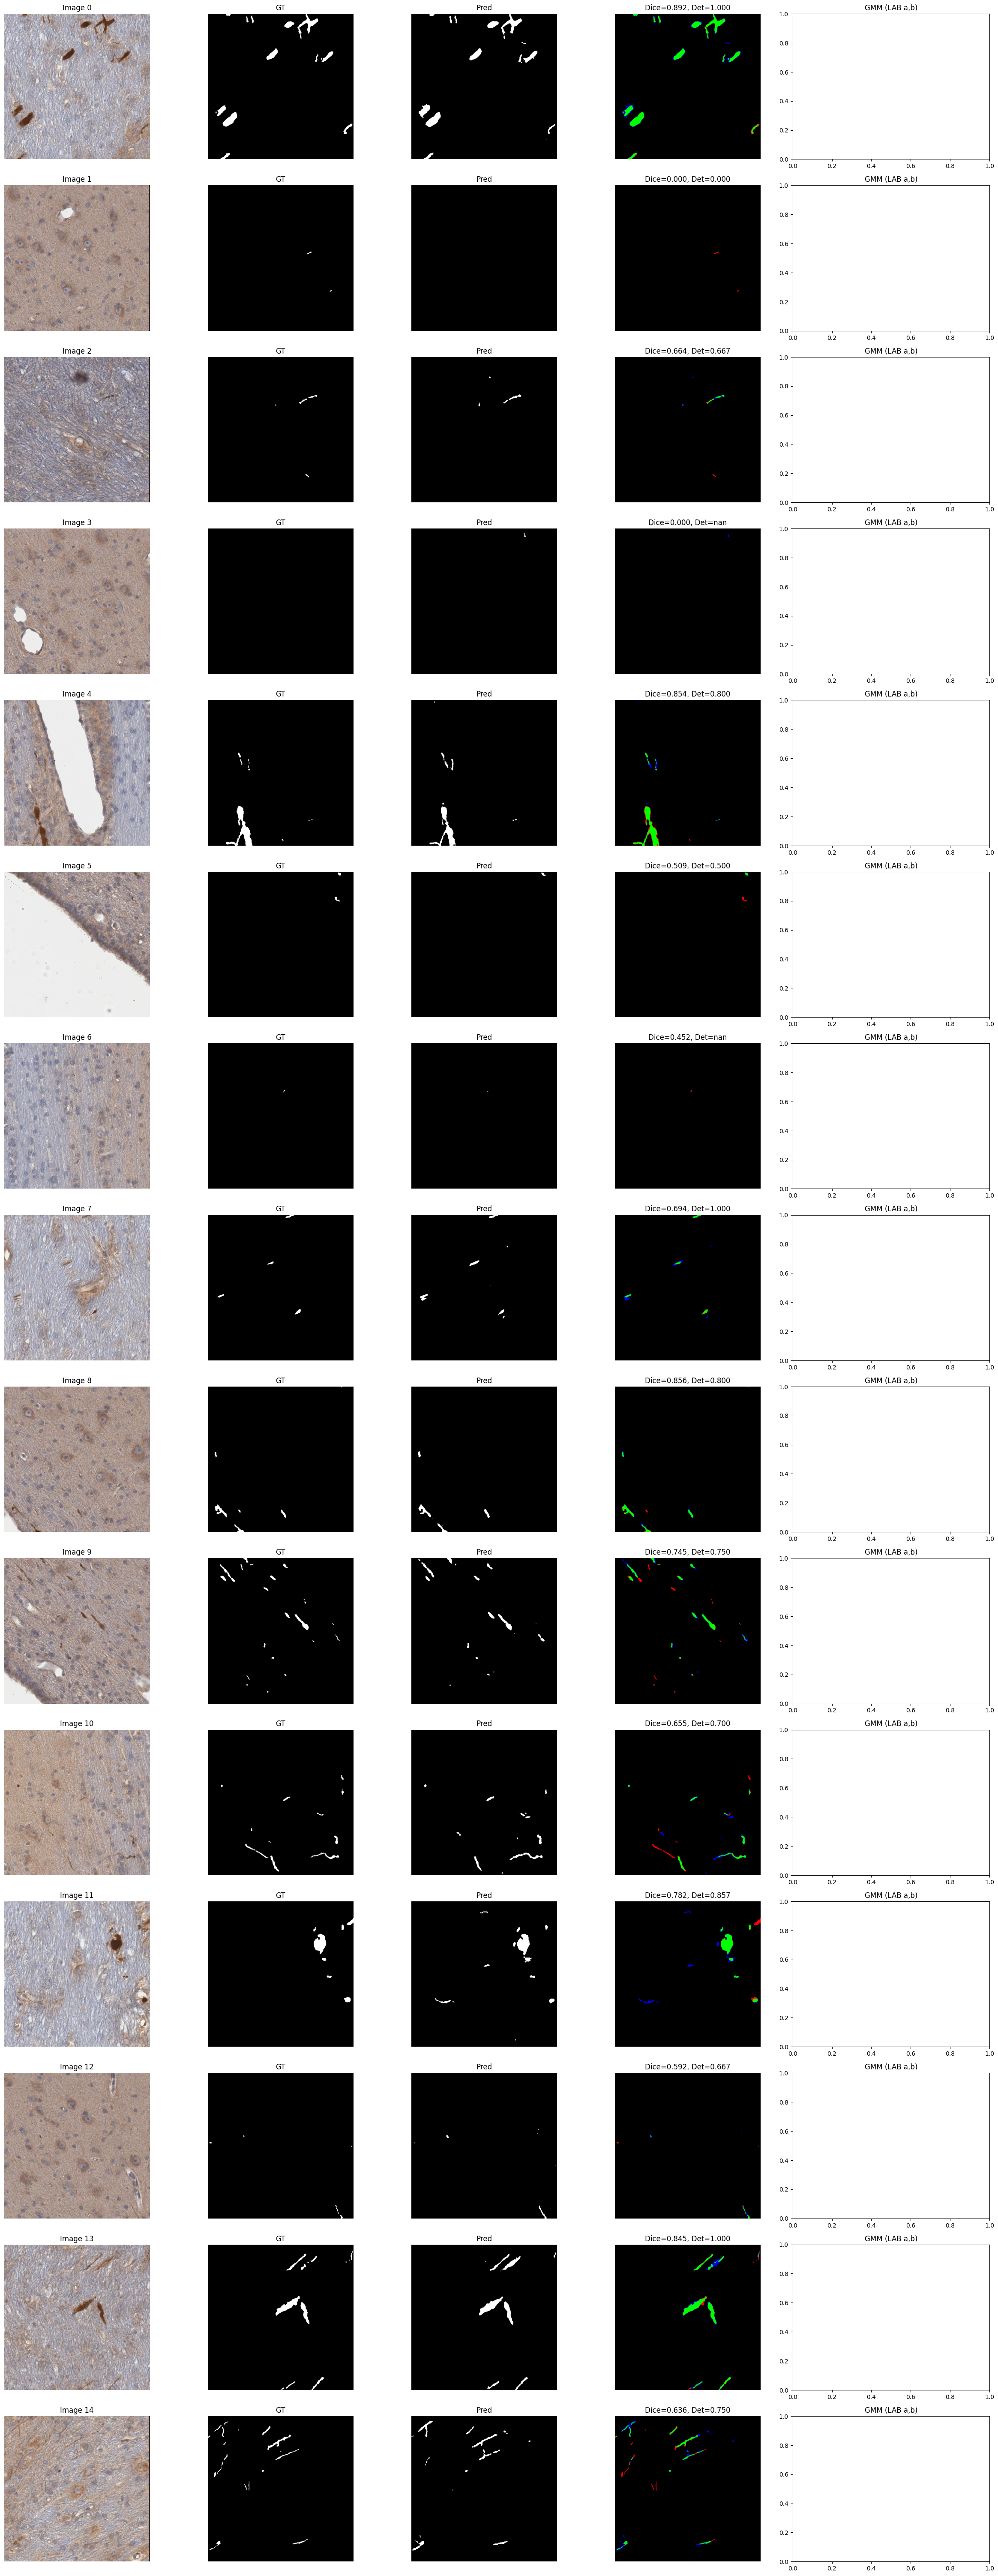


===== SUMMARY =====
Dataset: PushkarA07/2016-5-P2-dataset-new
N used: 15
Mean Dice: 0.6116511019860074
Global Det: 0.7978723404255319   (75/94)


In [5]:
# ============================================================
# ONE CELL: Load latest checkpoint + test on HF dataset_ids
# - choose dataset from list
# - patch sampling
# - Dice / IoU / Detection rate
# - Error map visualization
# ============================================================

import os, re, random
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2
from PIL import Image

from datasets import load_dataset
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

# ===================== EDIT =====================

EXP_DIRS = [
    "segformer-rerun-equal-epochs/E1Round1/PushkarA07_segformer-b0-finetuned-net-15Oct",
    "segformer-rerun-equal-epochs/E1Round2/PushkarA07_segformer-b0-finetuned-net-15Oct",
    "segformer-rerun-equal-epochs/E1Round3/PushkarA07_segformer-b0-finetuned-net-15Oct",
    "segformer-rerun-equal-epochs/Exp3_norm/PushkarA07_segformer-b0-finetuned-net-15Oct",
    "segformer-rerun-equal-epochs/Exp3_unnorm/PushkarA07_segformer-b0-finetuned-net-15Oct",
    "segformer-rerun-equal-epochs/E1Round1_old/PushkarA07_segformer-b0-finetuned-net-15Oct",
    "segformer-rerun-equal-epochs/E1Round2_old/PushkarA07_segformer-b0-finetuned-net-15Oct",
    "segformer-rerun-equal-epochs/E1Round3_old/PushkarA07_segformer-b0-finetuned-net-15Oct",


]
EXP_INDEX =0  # <2,7-- pick experiment here

DATASET_IDS = [
    "PushkarA07/2017-1-A3-dataset-new",
    "PushkarA07/2016-6-A1-dataset-new",
    "PushkarA07/2016-5-A2-dataset-new",
    "PushkarA07/2016-5-P2-dataset-new",
]

DATASET_INDEX =3     # <-- choose dataset here
SPLIT = "test"

N_SAMPLES = 25
PATCH = 512
MIN_MASK_PIXELS = 10
MIN_CC_AREA = 25
SEED = 0

# ============================================================

IGNORE = 255

if SEED is not None:
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)


def remove_large_elongated_components(pred, min_area=800, elong_thresh=3.0, connectivity=8):
    """
    Remove predicted connected components that look like big elongated vessels.
    Sets them to background (0).
    """
    pr = (pred > 0).astype(np.uint8)
    nlab, lab = cv2.connectedComponents(pr, connectivity=connectivity)

    out = pr.copy()

    for k in range(1, nlab):
        cc = (lab == k)
        area = int(cc.sum())
        if area < int(min_area):
            continue

        cnts, _ = cv2.findContours(cc.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not cnts:
            continue
        cnt = max(cnts, key=cv2.contourArea)

        rect = cv2.minAreaRect(cnt)
        (w, h) = rect[1]
        if w <= 0 or h <= 0:
            continue

        elong = max(w, h) / (min(w, h) + 1e-6)

        # If it's a big elongated thing -> kill it
        if elong >= float(elong_thresh):
            out[cc] = 0

    return out.astype(np.uint8)
# ---------------- LATEST CHECKPOINT ----------------
def find_latest_checkpoint_recursive(root):
    best_step, best_path = -1, None
    for dirpath, dirnames, _ in os.walk(root):
        for d in dirnames:
            m = re.match(r"checkpoint-(\d+)$", d)
            if m:
                step = int(m.group(1))
                p = os.path.join(dirpath, d)
                if step > best_step:
                    best_step, best_path = step, p
    return best_path, best_step

CKPT_DIR, CKPT_STEP = find_latest_checkpoint_recursive(EXP_DIRS[EXP_INDEX])

# print("EXP_DIR:", EXP_DIR)
print("Latest checkpoint:", CKPT_DIR, "step:", CKPT_STEP)
assert CKPT_DIR is not None

# ---------------- MODEL ----------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

processor = SegformerImageProcessor(do_resize=True, do_normalize=True)
model = SegformerForSemanticSegmentation.from_pretrained(
    CKPT_DIR,
    local_files_only=True
).to(device).eval()

# ---------------- DATASET ----------------
DATASET_ID = DATASET_IDS[DATASET_INDEX]
print("\nUsing dataset:", DATASET_ID)

ds = load_dataset(DATASET_ID)[SPLIT]
print("Dataset size:", len(ds))
print("Keys:", ds[0].keys())

import numpy as np
import cv2
import torch
from torch import nn

import cv2, numpy as np

def debug_pred_components(pred, img_rgb, topk=10):
    pr = (pred > 0).astype(np.uint8)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    nlab, lab = cv2.connectedComponents(pr, connectivity=8)

    rows = []
    for k in range(1, nlab):
        mask = (lab == k).astype(np.uint8)
        area = int(mask.sum())
        if area == 0:
            continue

        cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not cnts:
            continue
        cnt = max(cnts, key=cv2.contourArea)

        perim = cv2.arcLength(cnt, True)
        circ = 4*np.pi*(cv2.contourArea(cnt)/(perim*perim)) if perim > 1e-6 else 0.0

        # elongation via minAreaRect (works even for small contours)
        rect = cv2.minAreaRect(cnt)
        (w, h) = rect[1]
        elong = (max(w,h) / (min(w,h)+1e-6)) if (w > 0 and h > 0) else 1.0

        mean_int = float(gray[mask.astype(bool)].mean())
        std_int  = float(gray[mask.astype(bool)].std())

        # solidity
        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        sol = (cv2.contourArea(cnt) / hull_area) if hull_area > 1e-6 else 1.0

        rows.append((area, circ, elong, sol, mean_int, std_int))

    rows.sort(key=lambda x: x[0], reverse=True)
    print("area, circularity, elongation, solidity, mean_int, std_int")
    for r in rows[:topk]:
        print([round(x, 3) if isinstance(x, float) else x for x in r])


def predict_with_context(model, processor, img_rgb, out_hw, device="cuda", pad=64):
    """
    img_rgb: HxWx3 uint8
    out_hw : (H,W) of the desired output (e.g., gt.shape)
    pad    : context pixels around the patch
    """
    H, W = img_rgb.shape[:2]
    img_pad = cv2.copyMakeBorder(img_rgb, pad, pad, pad, pad, borderType=cv2.BORDER_REFLECT_101)

    inputs = processor(images=[img_pad], return_tensors="pt").to(device)

    with torch.no_grad():
        logits = model(**inputs).logits  # (1,C,h,w)

    # resize logits back to padded size
    logits = nn.functional.interpolate(logits, size=img_pad.shape[:2], mode="bilinear", align_corners=False)

    pred_pad = logits.argmax(dim=1)[0].detach().cpu().numpy().astype(np.uint8)  # (Hp,Wp)

    # crop back to original image region
    pred = pred_pad[pad:pad+H, pad:pad+W]

    # if caller wants specific out_hw, resize (nearest)
    if pred.shape != tuple(out_hw):
        pred = cv2.resize(pred, (out_hw[1], out_hw[0]), interpolation=cv2.INTER_NEAREST)

    return pred


# ---------------- HELPERS ----------------
def to_rgb(x):
    return np.array(Image.fromarray(np.uint8(x)).convert("RGB"))

def to_lbl(x):
    x = np.array(Image.fromarray(np.uint8(x)).convert("L"))
    x[(x >= 0) & (x <= 227)] = 0
    x[(x >= 228) & (x <= 255)] = 1
    return x.astype(np.uint8)

def dice_iou_binary(gt, pr, eps=1e-7):
    gt = (gt > 0).astype(np.uint8)
    pr = (pr > 0).astype(np.uint8)
    inter = (gt & pr).sum()
    union = gt.sum() + pr.sum() - inter
    dice = (2*inter + eps) / (gt.sum() + pr.sum() + eps)
    iou  = (inter + eps) / (union + eps)
    return float(dice), float(iou)

import numpy as np
import cv2
import numpy as np
import cv2

def border_touching_small_gt_mask(gt_bin, edge_area_thresh=25, connectivity=8):
    """
    Returns a boolean mask of GT pixels that belong to components:
      - touch the patch border
      - AND area < edge_area_thresh
    """
    gt = (gt_bin > 0).astype(np.uint8)
    H, W = gt.shape

    nlab, lab = cv2.connectedComponents(gt, connectivity=connectivity)
    ignore = np.zeros((H, W), dtype=bool)

    for k in range(1, nlab):
        cc = (lab == k)
        area = int(cc.sum())
        if area == 0:
            continue

        # touches border?
        touches = (
            cc[0, :].any() or cc[H-1, :].any() or
            cc[:, 0].any() or cc[:, W-1].any()
        )

        if touches and area < int(edge_area_thresh):
            ignore |= cc

    return ignore


def dice_iou_binary_ignore(gt, pr, ignore_mask=None, eps=1e-7):
    """
    Binary Dice/IoU, optionally ignoring certain pixels (ignore_mask=True).
    We remove ignored pixels from BOTH gt and pred so they don't affect FP/FN.
    """
    gt = (gt > 0).astype(np.uint8)
    pr = (pr > 0).astype(np.uint8)

    if ignore_mask is not None:
        gt = gt.copy()
        pr = pr.copy()
        gt[ignore_mask] = 0
        pr[ignore_mask] = 0

    inter = (gt & pr).sum()
    union = gt.sum() + pr.sum() - inter
    dice = (2 * inter + eps) / (gt.sum() + pr.sum() + eps)
    iou  = (inter + eps) / (union + eps)
    return float(dice), float(iou)


def count_detected_components_ignore_edges(
    gt,
    pr,
    min_cc_area=10,
    min_pr_cc_area=10,
    close_r=2,
    pred_dilate_r=1,
    edge_area_thresh=25,
    connectivity=8,
):
    """
    Detection rate where GT components that are:
      - border-touching AND small (area < edge_area_thresh)
    are NOT counted in total nor detected.

    Returns: (detected_components, total_components)
    """
    gt = (gt > 0).astype(np.uint8)
    pr = (pr > 0).astype(np.uint8)

    # 1) Close GT (merge small gaps)
    if close_r > 0:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*close_r+1, 2*close_r+1))
        gt = cv2.morphologyEx(gt, cv2.MORPH_CLOSE, k, iterations=1)

    # 2) Dilate pred (tolerance)
    if pred_dilate_r > 0:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*pred_dilate_r+1, 2*pred_dilate_r+1))
        pr = cv2.dilate(pr, k, iterations=1)

    # 3) Remove tiny predicted components
    if min_pr_cc_area is not None and min_pr_cc_area > 0:
        npr, pr_labels = cv2.connectedComponents(pr, connectivity=connectivity)
        pr_f = np.zeros_like(pr)
        for lab in range(1, npr):
            cc = (pr_labels == lab)
            if int(cc.sum()) >= int(min_pr_cc_area):
                pr_f[cc] = 1
        pr = pr_f

    # 4) Count GT components (skip small border-touching ones)
    H, W = gt.shape
    nlabels, labels = cv2.connectedComponents(gt, connectivity=connectivity)

    total = 0
    detected = 0

    for lab in range(1, nlabels):
        cc = (labels == lab)
        area = int(cc.sum())
        if area < int(min_cc_area):
            continue

        touches = (
            cc[0, :].any() or cc[H-1, :].any() or
            cc[:, 0].any() or cc[:, W-1].any()
        )

        # skip “tiny edge” GT components
        if touches and area < int(edge_area_thresh):
            continue

        total += 1
        if pr[cc].any():
            detected += 1

    return detected, total


def remove_big_oneclass_bulbs_gmm_lab(
    pred,
    img_rgb,
    min_area=400,
    max_elong=1.6,
    min_circ=0.55,
    min_sol=0.85,
    sep_thresh=8.0,        # LAB distance (not gray)
    min_minor_frac=0.08,
    debug=False,
):
    pr = (pred > 0).astype(np.uint8)
    lab_img = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
    ab_img = lab_img[:, :, 1:3].astype(np.float32)  # (H,W,2)

    nlab, lab_cc = cv2.connectedComponents(pr, connectivity=8)
    out = pr.copy()

    for kk in range(1, nlab):
        mask = (lab_cc == kk).astype(np.uint8)
        area = int(mask.sum())
        if area < min_area:
            continue

        cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not cnts:
            continue
        cnt = max(cnts, key=cv2.contourArea)

        perim = cv2.arcLength(cnt, True)
        circ = 4*np.pi*(cv2.contourArea(cnt)/(perim*perim)) if perim > 1e-6 else 0.0

        rect = cv2.minAreaRect(cnt)
        (w, h) = rect[1]
        elong = (max(w, h) / (min(w, h) + 1e-6)) if (w > 0 and h > 0) else 1.0

        hull = cv2.convexHull(cnt)
        hull_area = cv2.contourArea(hull)
        sol = (cv2.contourArea(cnt) / hull_area) if hull_area > 1e-6 else 1.0

        # bulb candidate by shape
        if not (elong <= max_elong and circ >= min_circ and sol >= min_sol):
            continue

        ys, xs = np.where(mask == 1)
        if ys.size < 50:
            continue

        samples = ab_img[ys, xs].reshape(-1, 2)

        em = cv2.ml.EM_create()
        em.setClustersNumber(2)
        em.setCovarianceMatrixType(cv2.ml.EM_COV_MAT_SPHERICAL)
        em.setTermCriteria((cv2.TERM_CRITERIA_COUNT + cv2.TERM_CRITERIA_EPS, 100, 1e-4))

        ok = em.trainEM(samples)
        if not ok:
            continue

        means = em.getMeans().astype(np.float32)           # (2,2)
        weights = em.getWeights().flatten().astype(float)  # (2,)

        sep = float(np.linalg.norm(means[0] - means[1]))   # LAB distance
        minor_frac = float(np.min(weights))

        if debug:
            print("BULB CAND:",
                  "area", area,
                  "circ", round(circ,3),
                  "elong", round(elong,3),
                  "sol", round(sol,3),
                  "sep(LAB)", round(sep,3),
                  "minor", round(minor_frac,3))

        # one-class test
        if (sep < sep_thresh) or (minor_frac < min_minor_frac):
            out[mask.astype(bool)] = 0

    return out.astype(np.uint8)


def gmm_patch_mask(img_rgb, k=2, sample_stride=2, use_ab=True, debug=False):
    """
    Fit GMM on the WHOLE patch (train on subsample for speed),
    then predict cluster for EVERY pixel and return:
      keep_mask: uint8 {0,1} mask of chosen cluster (optional use)
      vis      : RGB cluster visualization for the whole patch
    """

    H, W = img_rgb.shape[:2]
    lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    L  = lab[:, :, 0]
    ab = lab[:, :, 1:3]

    # ---- train samples (subsample) ----
    ys = np.arange(0, H, sample_stride, dtype=np.int32)
    xs = np.arange(0, W, sample_stride, dtype=np.int32)
    yy, xx = np.meshgrid(ys, xs, indexing="ij")

    if use_ab:
        train_samples = ab[yy, xx].reshape(-1, 2)
    else:
        train_samples = L[yy, xx].reshape(-1, 1)

    train_samples = np.ascontiguousarray(train_samples, dtype=np.float32)

    em = cv2.ml.EM_create()
    em.setClustersNumber(int(k))
    em.setCovarianceMatrixType(cv2.ml.EM_COV_MAT_SPHERICAL)
    em.setTermCriteria((cv2.TERM_CRITERIA_COUNT + cv2.TERM_CRITERIA_EPS, 100, 1e-4))

    ok = em.trainEM(train_samples)
    if not ok:
        keep = np.ones((H, W), dtype=np.uint8)
        vis = np.zeros((H, W, 3), dtype=np.uint8)
        return keep, vis

    # ---- predict for ALL pixels ----
    if use_ab:
        all_samples = ab.reshape(-1, 2)
    else:
        all_samples = L.reshape(-1, 1)

    all_samples = np.ascontiguousarray(all_samples, dtype=np.float32)

    # Use predict2 to get posterior probabilities robustly
    try:
        _, probs = em.predict2(all_samples)  # probs: (N, k)
        probs = np.asarray(probs)
        labels = np.argmax(probs, axis=1).astype(np.int32)
    except Exception:
        # Fallback: use em.predict and interpret output
        _, out = em.predict(all_samples)
        out = np.asarray(out)

        # If out is Nx1 labels -> good
        if out.ndim == 2 and out.shape[1] == 1:
            labels = out.reshape(-1).astype(np.int32)
        # If out is NxK probs -> argmax
        elif out.ndim == 2 and out.shape[1] == k:
            labels = np.argmax(out, axis=1).astype(np.int32)
        else:
            raise ValueError(f"Unexpected EM.predict output shape: {out.shape}")

    labels2d = labels.reshape(H, W)

    # Choose a "keep cluster" (only relevant if you later want gating)
    keep_cluster = 0
    best_score = -1e9
    for c in range(k):
        m = (labels2d == c)
        if m.sum() < 50:
            continue
        meanL = float(L[m].mean())
        score = -meanL   # darker => tissue-ish
        if score > best_score:
            best_score = score
            keep_cluster = c
    keep_mask = (labels2d == keep_cluster).astype(np.uint8)

    # Visualization colors
    palette = np.array([
        [255,255,0],
        [255,0,255],
        [0,255,0],
        [0,255,255],
    ], dtype=np.uint8)
    vis = palette[labels2d % len(palette)]

    if debug:
        uniq, cnt = np.unique(labels2d, return_counts=True)
        print("GMM labels:", dict(zip(uniq.tolist(), cnt.tolist())), "keep_cluster:", keep_cluster)

    return keep_mask, vis





def error_rgb(gt, pr):
    gt = (gt > 0)
    pr = (pr > 0)

    tp = gt & pr
    fn = gt & (~pr)
    fp = (~gt) & pr

    out = np.zeros((*gt.shape, 3), dtype=np.uint8)
    out[tp] = (0,255,0)
    out[fn] = (255,0,0)
    out[fp] = (0,0,255)
    return out

# ---------------- EVAL ----------------
all_dice, all_iou, all_det = [], [], []

MAX_PLOT = min(N_SAMPLES, 350)
plt.figure(figsize=(24, 4*MAX_PLOT))  # wider for 5 columns

DET_NUM = 0
DET_DEN = 0
idxs = np.random.choice(len(ds), size=min(N_SAMPLES, len(ds)), replace=False)
idxs = range(len(ds))
for k, idx in enumerate(idxs):
    # sample = ds[random.randint(0, len(ds)-1)]
    sample = ds[int(idx)]
    

    img_full = to_rgb(sample["pixel_values"])
    gt_full  = to_lbl(sample["label"])

    H, W = img_full.shape[:2]
    if H < PATCH or W < PATCH:
        continue

    # patch sampling (prefer positive)
    for _ in range(80):
        x = random.randint(0, W-PATCH)
        y = random.randint(0, H-PATCH)
        if gt_full[y:y+PATCH, x:x+PATCH].sum() > MIN_MASK_PIXELS:
            break

    img = img_full[y:y+PATCH, x:x+PATCH]
    gt  = gt_full[y:y+PATCH, x:x+PATCH]

    inputs = processor(images=[img], return_tensors="pt").to(device)

    with torch.no_grad():
        logits = model(**inputs).logits

    pred = torch.nn.functional.interpolate(
        logits,
        size=gt.shape,
        mode="bilinear",
        align_corners=False
    ).argmax(dim=1)[0].cpu().numpy().astype(np.uint8)
    pred = remove_large_elongated_components(pred, min_area=2300, elong_thresh=3.0)

    # ---- optional postprocessing ----
    # pred = remove_big_oneclass_bulbs_gmm_lab(
    #     pred, img,
    #     sep_thresh=12.0,      # was 8.0
    #     min_minor_frac=0.45,  # was 0.08
    #     debug=True
    # )


    # ---- metrics ----
    dice, iou = dice_iou_binary(gt, pred)
    # det_hit, det_tot = count_detected_components(gt, pred, min_cc_area=MIN_CC_AREA, min_pr_cc_area=MIN_CC_AREA)
    # ---- ignore tiny GT edge components (build mask from GT patch) ----
    ignore_mask = border_touching_small_gt_mask(gt, edge_area_thresh=50)

    # ---- metrics ----
    dice, iou = dice_iou_binary_ignore(gt, pred, ignore_mask=ignore_mask)
    det_hit, det_tot = count_detected_components_ignore_edges(
        gt, pred,
        min_cc_area=MIN_CC_AREA,
        min_pr_cc_area=MIN_CC_AREA,
        edge_area_thresh=MIN_CC_AREA
    )

    DET_NUM += det_hit
    DET_DEN += det_tot
    det = (det_hit / det_tot) if det_tot > 0 else np.nan

    all_dice.append(dice)
    all_iou.append(iou)
    all_det.append(det)
    # gmm_keep, gmm_full_vis = gmm_patch_mask(img, k=4, sample_stride=1, use_ab=False)
# 

    # ---- visualization ----
    if k < MAX_PLOT:
        err = error_rgb(gt, pred)
        gmm_vis = None

        plt.subplot(MAX_PLOT, 5, 5*k+1)
        plt.imshow(img); plt.axis("off")
        plt.title(f"Image {k}")

        plt.subplot(MAX_PLOT, 5, 5*k+2)
        plt.imshow(gt, cmap="gray"); plt.axis("off")
        plt.title("GT")

        plt.subplot(MAX_PLOT, 5, 5*k+3)
        plt.imshow(pred, cmap="gray"); plt.axis("off")
        plt.title("Pred")

        plt.subplot(MAX_PLOT, 5, 5*k+4)
        plt.imshow(err); plt.axis("off")
        plt.title(f"Dice={dice:.3f}, Det={det:.3f}")

        plt.subplot(MAX_PLOT, 5, 5*k+5)
        # plt.imshow(gmm_vis); plt.axis("off")
        plt.title("GMM (LAB a,b)")

plt.tight_layout()
plt.show()

global_det = (DET_NUM / DET_DEN) if DET_DEN > 0 else np.nan

print("\n===== SUMMARY =====")
print("Dataset:", DATASET_ID)
print("N used:", len(all_dice))
print("Mean Dice:", float(np.nanmean(all_dice)))
print("Global Det:", float(global_det), f"  ({DET_NUM}/{DET_DEN})")

